# 2.5: Notebook-Plotting with Matplotlib 1

This notebook contains some exercises, but you should also:
- use examples from the Matplotlib lessons or the documentation to practice what you've learned,
- look up the plotting functions to find more optional parameters and see what they do.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import pandas as pd
import random

## Exercise 1
Use the documentation to find out how to draw no line at all, only the data points, and modify this example accordingly.

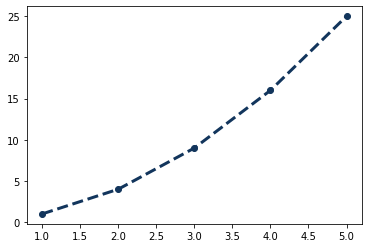

In [2]:
fig, ax = plt.subplots() 
ax.plot([1,2,3,4,5], [1,4,9,16,25], linestyle='--', marker='o', color='#12355C', linewidth=3)

## Exercise 2
In the scatter plot, try making the size of the data points proportional to their value.
When you do this, you might find that the uppermost point is too large and gets cut off.
Make the y axis longer so that the whole marker is displayed.

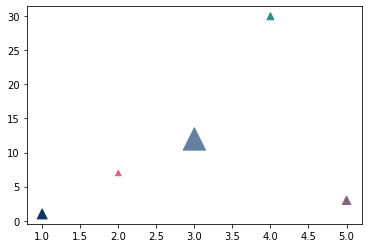

In [3]:
fig, ax = plt.subplots() 
scatter_data = pd.DataFrame({
    "x data": [1,2,3,4,5],
    "y data": [1,7,12,30,3]
})
ax.scatter(
    'x data',
    'y data',
    data=scatter_data,
    s=[100,30,500,50,70], 
    c=['#12355C', '#D86175', '#6481A2', '#2B8F84', '#806480'],
    marker='^'
)

## Exercise 3
In this example, two data sets are plotted together in a bar chart. 
In the second subplot, present the same data in a stacked bar chart. 
To create a stacked bar chart, both data sets must have the same position for each bar on the x axis, and the second bar of the second data set will need to begin where the first ended – if you're not too sure what a stacked bar chart is or want some hints have a look at this [example](https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_stacked.html#sphx-glr-gallery-lines-bars-and-markers-bar-stacked-py).

For the third and fourth subplots, you should add a third set of data and display this using a grouped and stacked plot, respectively. 
In all cases, add labels for the data and a legend.
Finally, modify the figure so that all the plots share the same y axis and are therefore displayed to the same scale. 

Finally, think about whether you could restructure your code to have a function for drawing grouped plots and a function for drawing stacked plots. 

<BarContainer object of 5 artists>

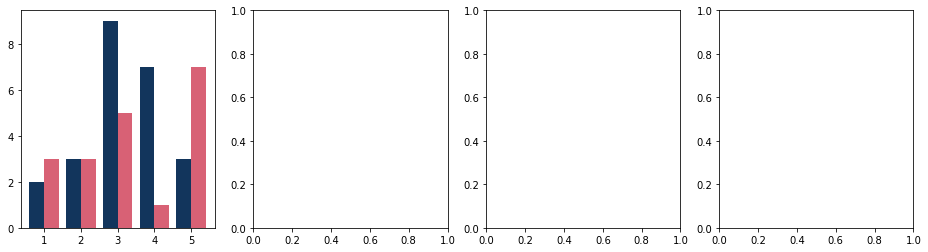

In [4]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
x = np.array([1,2,3,4,5])
y1 = [2,3,9,7,3]
y2 = [3,3,5,1,7]
bar_width = 0.4
axs[0].bar(x-0.2, y1, bar_width, color='#12355C')
axs[0].bar(x+0.2, y2, bar_width, color='#D86175')

## Exercise 4
The function ``barh()`` works in a similar way to ``bar()`` to create a horizontal bar graph. Find out how to modify the below example to generate a horizontal bar graph of the same data, with error bars, in the second Axes.

<ErrorbarContainer object of 3 artists>

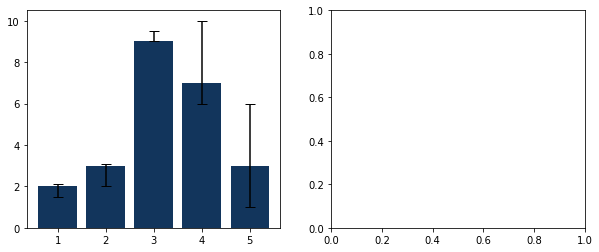

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
# create a bar chart
axs[0].bar([1,2,3,4,5], [2,3,9,7,3], color='#12355C')
# add error bars
axs[0].errorbar(
    [1,2,3,4,5],
    [2,3,9,7,3],
    yerr=[[0.5, 1, 0, 1, 2],[0.1, 0.1, 0.5, 3, 3]],
    linestyle='',
    color='black',
    capsize=5)

## Exercise 5

In the lesson on frequency distributions, we had the following functions to generate sums of dice rolls and plot the frequency of the result. 
Modify the functions to add a box plot below the bar chart. 
The box plot should show the distribution of all the data points generated by each of the `n_samples` calls to `random_function`.
Pass in the optional argument `vert=False` to make the boxplot show horizontally instead of vertically.

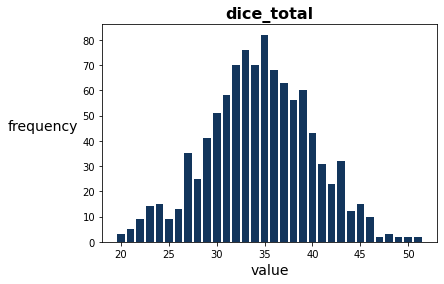

In [6]:
def dice_total(num, sides):
    total = 0
    for roll in range(num):
        total += random.randint(1, sides)
    return total

def get_freq_of_random_function(n_samples, random_function, *func_args):
    """ 
        calls a provided function for generating random numbers
        
        Parameters:
            n_samples (int): the number of times to call the function
            random_function: a function to generate a single item of data
            *func_args: any arguments required for random_function
        
        Returns:
            dictionary of values: frequencies
    """
    freq = {}  # initialise
    
    for tests in range(n_samples):
        # call the random function and pass in any arguments provided for it
        result = random_function(*func_args)
        # update frequency record with this result
        if result in freq:
            freq[result] += 1
        else:
            freq[result] = 1
    
    return freq

def plot_freq_dist(frequencies, plot_title):
    """
        bar chart of given frequency distribution
        
        Parameters:
            frequencies dict(float: int): dictionary of value: frequency of value
            plot_title (str): title of the plot
        
        Returns: 
            matplotlib figure
    """
    # prepare figure area
    fig, ax = plt.subplots()
    ax.set_title(plot_title, fontsize=16, fontweight='bold')
    
    # plot bars
    ax.bar(frequencies.keys(), frequencies.values(), color='#12355C')
    # axes labels
    ax.set_xlabel('value', fontsize=14)
    ax.set_ylabel('frequency', fontsize=14, rotation=0, labelpad=40)
    return fig
    
frequencies = get_freq_of_random_function(1000, dice_total, 10, 6)
fig = plot_freq_dist(frequencies, 'dice_total')
plt.show()

## Solutions to exercises
### 1

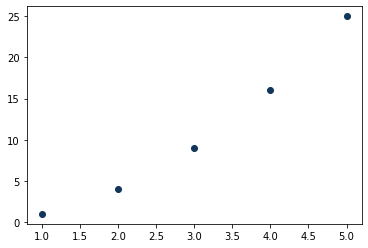

In [7]:
fig, ax = plt.subplots() 
ax.plot([1,2,3,4,5], [1,4,9,16,25], linestyle='', marker='o', color='#12355C')

### 2
Pandas Series, like numpy arrays, apply mathematical operations componentwise, which is really convenient for scaling the y values to give sizes for each data point.

(-5.0, 40.0)

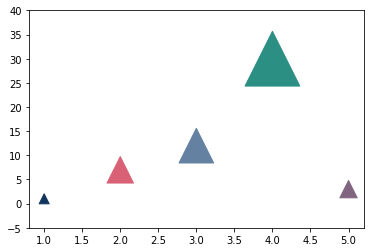

In [8]:
scatter_data = pd.DataFrame({
    "x data": [1,2,3,4,5],
    "y data": [1,7,12,30,3]
})
sizes = scatter_data['y data']*100
fig, ax = plt.subplots() 
ax.scatter(
    'x data',
    'y data',
    data=scatter_data,
    s=sizes, 
    c=['#12355C', '#D86175', '#6481A2', '#2B8F84', '#806480'],
    marker='^'
)
ax.set_ylim(-5, 40)

### 3

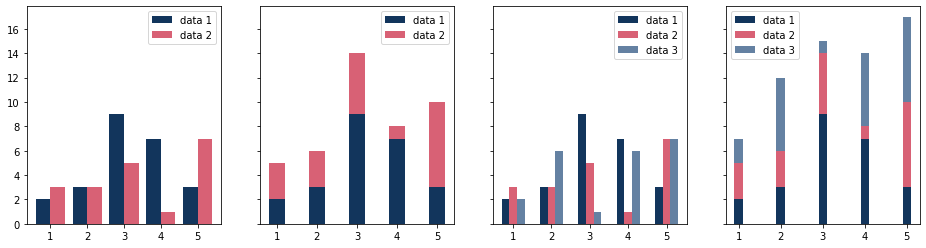

In [9]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
x = np.array([1,2,3,4,5])
y1 = [2,3,9,7,3]
y2 = [3,3,5,1,7]

# grouped bar chart
bar_width = 0.4
axs[0].bar(x-0.2, y1, bar_width, label='data 1', color='#12355C')
axs[0].bar(x+0.2, y2, bar_width, label='data 2', color='#D86175')
axs[0].legend()

# stacked bar chart
axs[1].bar(x, y1, bar_width, label='data 1', color='#12355C')
axs[1].bar(x, y2, bar_width, bottom=y1, label='data 2', color='#D86175')
axs[1].legend()

y3 = [2,6,1,6,7]  # third data set

# grouped bar chart
bar_width = 0.2  # narrower bars so they fit nicely along the x axis
axs[2].bar(x-0.2, y1, bar_width, label='data 1', color='#12355C')
axs[2].bar(x+0, y2, bar_width, label='data 2', color='#D86175')
axs[2].bar(x+0.2, y3, bar_width, label='data 3', color='#6481A2')
axs[2].legend()

# changing data to be in numpy arrays 
# makes it easier to add the values together componentwise
y1 = np.array(y1) 
y2 = np.array(y2)

# stacked bar chart
axs[3].bar(x, y1, bar_width, label='data 1', color='#12355C')
axs[3].bar(x, y2, bar_width, bottom=y1, label='data 2', color='#D86175')
axs[3].bar(x, y3, bar_width, bottom=y1+y2, label='data 3', color='#6481A2')
axs[3].legend()

We can make functions for drawing grouped and stacked bar plots as follows:

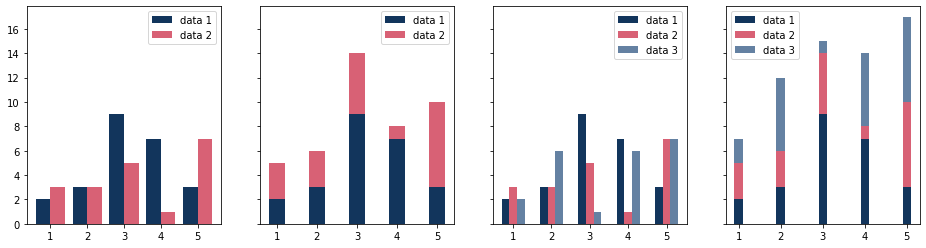

In [10]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
x = np.array([1,2,3,4,5])
y1 = [2,3,9,7,3]
y2 = [3,3,5,1,7]
y3 = [2,6,1,6,7]

# Define color palette
colors = ['#12355C', '#D86175', '#6481A2', '#2B8F84', '#806480']

def draw_grouped_bar(ax, x, bar_width, data_dict):
    # multiplier to decide how much to offset first bar
    # based on number of bars to be drawn
    m = -(len(data_dict)-1)/2
    
    for i, (label, y) in enumerate(data_dict.items()):
        ax.bar(x+(m*bar_width), y, bar_width, label=label, color=colors[i])
        m += 1
    ax.legend()
    
def draw_stacked_bar(ax, x, bar_width, data_dict):
    base = np.array([0]*len(x))
    for i, (label, y) in enumerate(data_dict.items()):
        ax.bar(x, y, bar_width, bottom=base, label=label, color=colors[i])
        # set starting positions for next data set
        base = base+np.array(y) 
    ax.legend()

# grouped bar chart
draw_grouped_bar(axs[0], x, 0.4, {'data 1': y1, 'data 2': y2})
# stacked bar chart
draw_stacked_bar(axs[1], x, 0.4, {'data 1': y1, 'data 2': y2})
# grouped bar chart - 3 data sets
draw_grouped_bar(axs[2], x, 0.2, {'data 1': y1, 'data 2': y2, 'data 3': y3})
# stacked bar chart - 3 data sets
draw_stacked_bar(axs[3], x, 0.2, {'data 1': y1, 'data 2': y2, 'data 3': y3})

### 4

<ErrorbarContainer object of 3 artists>

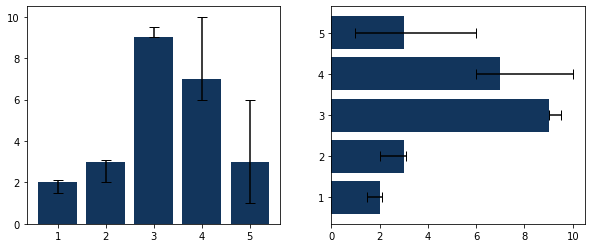

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
# create a bar chart
axs[0].bar([1,2,3,4,5], [2,3,9,7,3], color='#12355C')
# add error bars
axs[0].errorbar(
    [1,2,3,4,5],
    [2,3,9,7,3],
    yerr=[[0.5, 1, 0, 1, 2],[0.1, 0.1, 0.5, 3, 3]],
    linestyle='',
    color='black',
    capsize=5
)
# create a horizontal bar chart
axs[1].barh([1,2,3,4,5], [2,3,9,7,3], color='#12355C')
# add error bars - note the order of the first two arguments
axs[1].errorbar(
    [2,3,9,7,3],
    [1,2,3,4,5],
    xerr=[[0.5, 1, 0, 1, 2],[0.1, 0.1, 0.5, 3, 3]],
    linestyle='',
    color='black',
    capsize=5
)

### 5

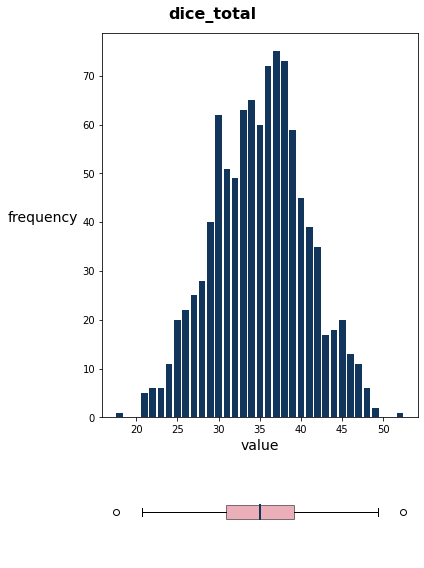

In [12]:
def dice_total(num, sides):
    total = 0
    for roll in range(num):
        total += random.randint(1, sides)
    return total

def get_freq_of_random_function(n_samples, random_function, *func_args):
    """ 
        calls a provided function for generating random numbers
        
        Parameters:
            n_samples (int): the number of times to call the function
            random_function: a function to generate a single item of data
            *func_args: any arguments required for random_function
        
        Returns:
            dictionary of values: frequencies
    """
    freq = {}  # initialise
    
    for tests in range(n_samples):
        # call the random function and pass in any arguments provided for it
        result = random_function(*func_args)
        # update frequency record with this result
        if result in freq:
            freq[result] += 1
        else:
            freq[result] = 1
    
    return freq

def plot_freq_dist(frequencies, fig_title):
    """
        bar chart and box plot of given frequency distribution
        
        Parameters:
            frequencies dict(float: int): dictionary of value: frequency of value
            fig_title (str): title of the figure
        
        Returns: 
            matplotlib figure
    """
    # prepare figure area
    fig = plt.figure(figsize=(6, 8))
    gs = GridSpec(4, 1, figure=fig)
    fig.suptitle(fig_title, fontsize=16, fontweight='bold')
    
    ax1 = fig.add_subplot(gs[:3, 0])
    ax2 = fig.add_subplot(gs[3:, 0])
    
    # plot bars
    ax1.bar(frequencies.keys(), frequencies.values(), color='#12355C')
    # axes labels
    ax1.set_xlabel('value', fontsize=14)
    ax1.set_ylabel('frequency', fontsize=14, rotation=0, labelpad=40)
    
    # values for box plot
    all_values = []
    for k, v in frequencies.items():
        all_values.extend([k]*v)
    
    # draw boxplot
    ax2.boxplot(all_values, vert=False, patch_artist=True,
                boxprops=dict(facecolor='#D86175', alpha=0.5),
                medianprops=dict(color='#12355C', linewidth=2))
    # remove axis / spines
    ax2.spines['right'].set_color('none')
    ax2.spines['bottom'].set_color('none')
    ax2.spines['top'].set_color('none')
    ax2.spines['left'].set_color('none')
    ax2.get_xaxis().set_visible(False)
    ax2.get_yaxis().set_visible(False)
    fig.tight_layout()
    return fig
    
frequencies = get_freq_of_random_function(1000, dice_total, 10, 6)
fig = plot_freq_dist(frequencies, 'dice_total')
plt.show()